# 🎾 Tercera Entrega - Proyecto Inteligencia Artificial 1

## Predicción de Resultados en Partidos de Tenis ATP (2000-2023)

**Autor:** Nicolas Echeverri Rueda
**Código:** 2231888
**Grupo:** E1

---

### 📌 Contenido del Notebook
Este notebook implementa la **Tercera Entrega** del proyecto, integrando:

1. **Análisis Exploratorio de Datos (EDA)**
2. **Preprocesamiento de datos** (limpieza, outliers, estandarización)
3. **Modelos de Clasificación Supervisada**: GNB, Decision Tree, Random Forest, SVM
4. **Modelo de Regresión** sobre una variable numérica relevante
5. **Deep Learning**: dos arquitecturas DNN diferentes con ablation study
6. **Aprendizaje No Supervisado**: K-Means y DBSCAN
7. **Reducción de Dimensionalidad**: PCA y t-SNE
8. **Tabla comparativa final y conclusiones**

Para cada modelo se reportan métricas (*accuracy, precision, recall, F1-score, especificidad*), visualizaciones y un ablation study que analiza el impacto de los hiperparámetros sobre el desempeño.


## 1. Importación de Librerías y Carga del Dataset

Se cargan todas las librerías necesarias para el análisis, el modelado clásico (`scikit-learn`), el aprendizaje profundo (`tensorflow.keras`) y las visualizaciones (`matplotlib`, `seaborn`).

In [1]:
# Librerías base
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn: preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn: modelos supervisados
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression

# Scikit-learn: métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             mean_squared_error, r2_score, silhouette_score, adjusted_rand_score)

# Scikit-learn: no supervisado y reducción de dimensionalidad
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

sns.set_theme(style="whitegrid")
print("Versión de TensorFlow:", tf.__version__)
print("Librerías cargadas correctamente ✅")

Versión de TensorFlow: 2.20.0
Librerías cargadas correctamente ✅


In [2]:
# Montaje de Google Drive y carga del dataset
from google.colab import drive
drive.mount('/content/drive')

ruta_zip = '/content/drive/MyDrive/archive.zip'
carpeta_destino = '/content/datos_tenis'

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(carpeta_destino)

df = pd.read_csv('/content/datos_tenis/atp_tennis.csv')
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Mounted at /content/drive
Dataset cargado: 67288 filas × 17 columnas


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Motivación, Problema y Datos
El **tenis profesional** es un deporte donde predecir el ganador implica considerar múltiples factores previos al encuentro. El dataset *ATP Tennis 2000-2023* (Kaggle) contiene el histórico de partidos del circuito ATP incluyendo:

- **Jugadores enfrentados** (`Player_1`, `Player_2`)
- **Torneo y contexto** (`Tournament`, `Surface`, `Round`, `Court`, `Series`)
- **Indicadores deportivos** (`Rank_1`, `Rank_2`, `Pts_1`, `Pts_2`)
- **Cuotas de apuestas** (`Odd_1`, `Odd_2`)
- **Ganador** (`Winner`)

**Problema:** determinar si las variables previas al encuentro permiten predecir el ganador con mayor precisión que simplemente "apostar al favorito".

### 2.2 Variable Objetivo
La variable objetivo es **`Victoria_P1`** (binaria), construida como:

$$\text{Victoria\_P1} = \begin{cases} 1 & \text{si } \text{Winner} = \text{Player\_1} \\ 0 & \text{en otro caso} \end{cases}$$

In [3]:
import pandas as pd

# 1. Lista de columnas que deben ser numéricas para las operaciones
cols_to_fix = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']

# 2. Convertir a numérico: 'errors=coerce' transforma textos no válidos en NaN
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Construcción de la variable objetivo y feature engineering
df['Victoria_P1'] = (df['Winner'] == df['Player_1']).astype(int)

# Ahora las restas funcionarán correctamente
df['Diff_Rank'] = df['Rank_1'] - df['Rank_2']
df['Diff_Pts']  = df['Pts_1']  - df['Pts_2']
df['Diff_Odd']  = df['Odd_1']  - df['Odd_2']

# 4. Impresión de resultados
print("Información general del dataset:")
print(df.info())
print("\nDistribución de la variable objetivo:")
print(df['Victoria_P1'].value_counts(normalize=True).rename('Proporción'))

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67288 entries, 0 to 67287
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tournament   67288 non-null  object 
 1   Date         67288 non-null  object 
 2   Series       67288 non-null  object 
 3   Court        67288 non-null  object 
 4   Surface      67288 non-null  object 
 5   Round        67288 non-null  object 
 6   Best of      67288 non-null  int64  
 7   Player_1     67288 non-null  object 
 8   Player_2     67288 non-null  object 
 9   Winner       67288 non-null  object 
 10  Rank_1       67288 non-null  int64  
 11  Rank_2       67288 non-null  int64  
 12  Pts_1        67288 non-null  int64  
 13  Pts_2        67288 non-null  int64  
 14  Odd_1        67288 non-null  float64
 15  Odd_2        67287 non-null  float64
 16  Score        67288 non-null  object 
 17  Victoria_P1  67288 non-null  int64  
 18  Diff_Rank    

### 2.3 Análisis de Variables

Según la **rúbrica de reporte de variables**, cada variable se grafica primero y se reporta con la estadística adecuada según su tipo y forma.

#### 2.3.1 Variable categórica: `Surface`
Se reporta con **frecuencia y porcentaje** (gráfico de barras y de pastel).

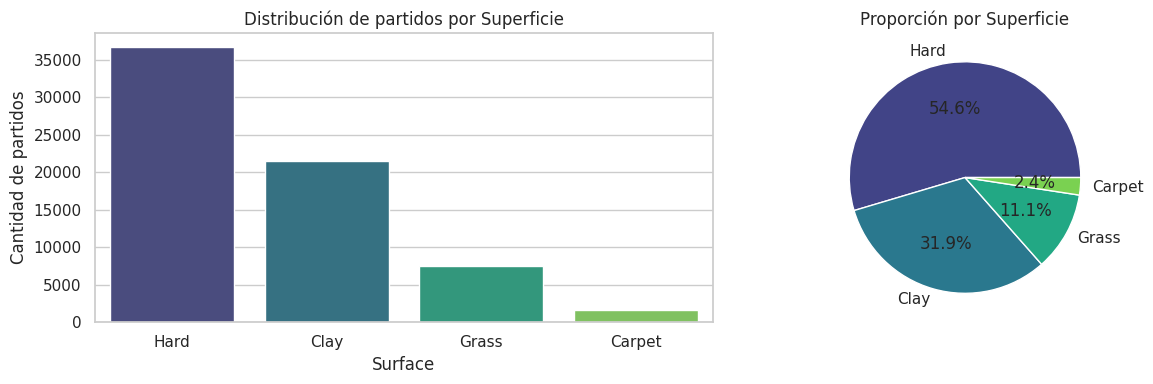

Reporte (frecuencia y porcentaje):
  • Hard: 36742 casos (54.6%)
  • Clay: 21470 casos (31.9%)
  • Grass: 7444 casos (11.1%)
  • Carpet: 1632 casos (2.4%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
frec = df['Surface'].value_counts()
porc = df['Surface'].value_counts(normalize=True) * 100

sns.barplot(x=frec.index, y=frec.values, palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de partidos por Superficie')
axes[0].set_ylabel('Cantidad de partidos')

axes[1].pie(frec.values, labels=frec.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', len(frec)))
axes[1].set_title('Proporción por Superficie')
plt.tight_layout(); plt.show()

print("Reporte (frecuencia y porcentaje):")
for sup, f, p in zip(frec.index, frec.values, porc.values):
    print(f"  • {sup}: {f} casos ({p:.1f}%)")

#### 2.3.2 Variable numérica simétrica: `Diff_Rank`
Histograma centrado tipo campana → se reporta con **media ± desviación estándar**.

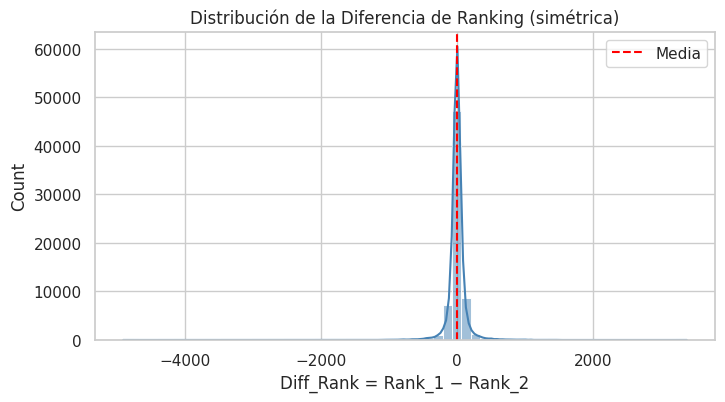

Diff_Rank promedio: 0.31 ± 137.61 posiciones


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Diff_Rank'].dropna(), kde=True, bins=60, color='steelblue')
plt.title('Distribución de la Diferencia de Ranking (simétrica)')
plt.xlabel('Diff_Rank = Rank_1 − Rank_2')
plt.axvline(df['Diff_Rank'].mean(), color='red', linestyle='--', label='Media')
plt.legend(); plt.show()

print(f"Diff_Rank promedio: {df['Diff_Rank'].mean():.2f} ± {df['Diff_Rank'].std():.2f} posiciones")

#### 2.3.3 Variable numérica asimétrica: `Odd_1`
Las cuotas de apuestas son sesgadas a la derecha (la mayoría de partidos tienen cuotas bajas para el favorito y unos pocos tienen cuotas muy altas) → se reporta con **mediana y rango intercuartil (IQR)**.

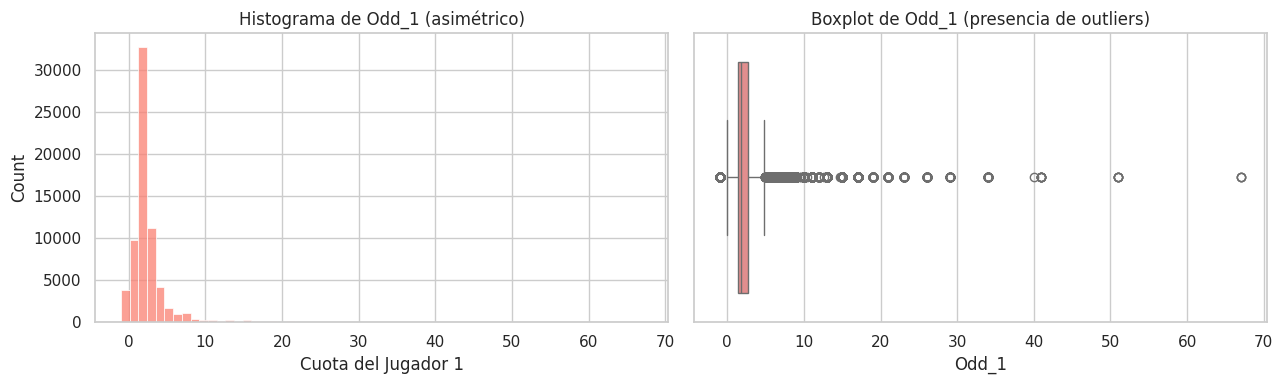

Odd_1 → Mediana: 1.75 | IQR: (1.34 − 2.75) | Rango total: (-1.00 − 67.00)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Odd_1'].dropna(), bins=60, color='salmon', ax=axes[0])
axes[0].set_title('Histograma de Odd_1 (asimétrico)')
axes[0].set_xlabel('Cuota del Jugador 1')

sns.boxplot(x=df['Odd_1'].dropna(), color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot de Odd_1 (presencia de outliers)')
plt.tight_layout(); plt.show()

med = df['Odd_1'].median(); q1 = df['Odd_1'].quantile(.25); q3 = df['Odd_1'].quantile(.75)
print(f"Odd_1 → Mediana: {med:.2f} | IQR: ({q1:.2f} − {q3:.2f}) | Rango total: ({df['Odd_1'].min():.2f} − {df['Odd_1'].max():.2f})")

#### 2.3.4 Análisis bivariado: relación de variables con `Victoria_P1`

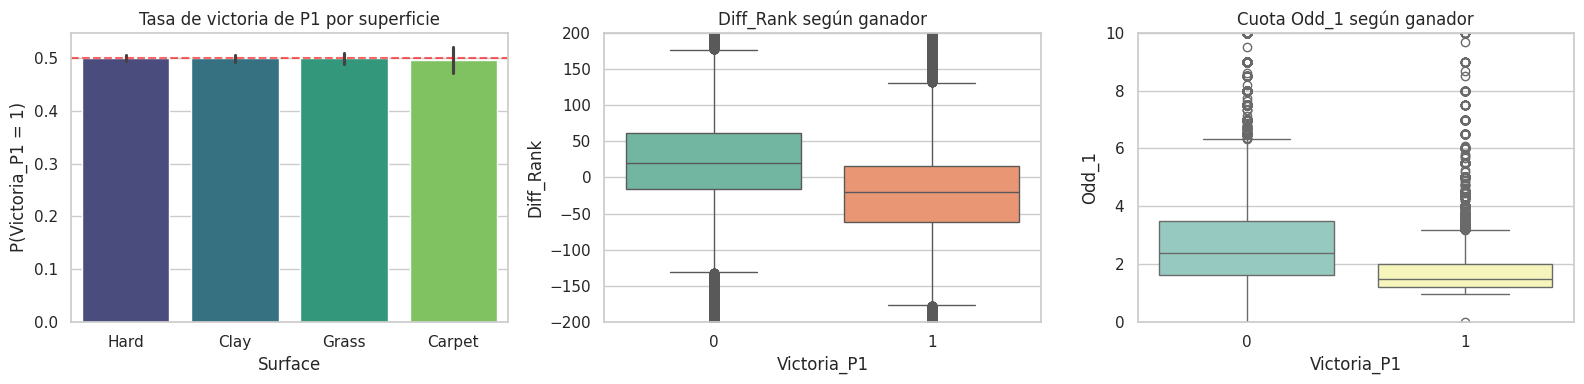

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Surface vs Victoria_P1
sns.barplot(data=df, x='Surface', y='Victoria_P1', palette='viridis', ax=axes[0])
axes[0].set_title('Tasa de victoria de P1 por superficie')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.6)
axes[0].set_ylabel('P(Victoria_P1 = 1)')

# Diff_Rank vs Victoria_P1
sns.boxplot(data=df, x='Victoria_P1', y='Diff_Rank', palette='Set2', ax=axes[1])
axes[1].set_title('Diff_Rank según ganador')
axes[1].set_ylim(-200, 200)

# Odd_1 vs Victoria_P1
sns.boxplot(data=df, x='Victoria_P1', y='Odd_1', palette='Set3', ax=axes[2])
axes[2].set_title('Cuota Odd_1 según ganador')
axes[2].set_ylim(0, 10)

plt.tight_layout(); plt.show()

**Lectura:** cuanto **menor es la cuota de P1** y **menor es Diff_Rank** (P1 tiene mejor ranking), mayor es la probabilidad de victoria de P1. La superficie tiene un efecto más sutil pero apreciable.

## 3. Preprocesamiento de Datos

Sección obligatoria según la rúbrica. Cada decisión se justifica con base en el comportamiento del dataset.

### 3.1 Manejo de valores nulos
**Estrategia:** imputación por **mediana** para variables numéricas, dado que la distribución de cuotas y rankings está sesgada (la mediana es robusta a outliers). Para categóricas se usa la moda.

In [8]:
print("Valores nulos por columna (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Imputación
cols_num = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2',
            'Diff_Rank', 'Diff_Pts', 'Diff_Odd']
for c in cols_num:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())

# Categóricas
for c in ['Surface', 'Court', 'Series', 'Round']:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].mode()[0])

print("\nNulos restantes:", df[cols_num].isnull().sum().sum())

Valores nulos por columna (top 10):
Diff_Odd      1
Odd_2         1
Series        0
Date          0
Tournament    0
Surface       0
Court         0
Round         0
Best of       0
Winner        0
dtype: int64

Nulos restantes: 0


### 3.2 Identificación y tratamiento de outliers
La gráfica de `Odd_1` mostró valores extremos (cuotas >20 en partidos muy desbalanceados). Aplicamos *winsorization* con el método del rango intercuartil (**IQR**) a las cuotas, conservando las observaciones pero acotando los valores extremos al límite del IQR. Esto **preserva la información sin distorsionar los modelos sensibles a escalas** (SVM, redes neuronales).

In [9]:
def winsorize_iqr(serie, k=3.0):
    q1, q3 = serie.quantile(.25), serie.quantile(.75)
    iqr = q3 - q1
    li, ls = q1 - k * iqr, q3 + k * iqr
    return serie.clip(lower=li, upper=ls), li, ls

for c in ['Odd_1', 'Odd_2']:
    antes = (df[c] > df[c].quantile(.75) + 3 * (df[c].quantile(.75) - df[c].quantile(.25))).sum()
    df[c], li, ls = winsorize_iqr(df[c])
    print(f"{c}: límites [{li:.2f}, {ls:.2f}] | outliers acotados: {antes}")

Odd_1: límites [-2.88, 6.97] | outliers acotados: 2905
Odd_2: límites [-2.92, 7.00] | outliers acotados: 2325


### 3.3 Codificación de variables categóricas
Se aplica **One-Hot Encoding** sobre `Surface` (variable nominal sin orden inherente). Para `Court` y `Series` también, aunque solo se incluyen si aparecen como relevantes.

In [10]:
# Selección de features para el modelado
features_num = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2',
                'Diff_Rank', 'Diff_Pts', 'Diff_Odd']
features_cat = ['Surface']

X = pd.get_dummies(df[features_num + features_cat], columns=features_cat, drop_first=True)
y = df['Victoria_P1']

print(f"Matriz de features X: {X.shape}")
print(f"Vector objetivo y:    {y.shape}")
print(f"Distribución de clases: {y.value_counts(normalize=True).round(3).to_dict()}")
X.head()

Matriz de features X: (67288, 12)
Vector objetivo y:    (67288,)
Distribución de clases: {1: 0.5, 0: 0.5}


,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Diff_Rank,Diff_Pts,Diff_Odd,Surface_Clay,Surface_Grass,Surface_Hard
0,63,77,-1,-1,-1.0,-1.0,-14,0,0.0,False,False,True
1,56,5,-1,-1,-1.0,-1.0,51,0,0.0,False,False,True
2,40,655,-1,-1,-1.0,-1.0,-615,0,0.0,False,False,True
3,87,65,-1,-1,-1.0,-1.0,22,0,0.0,False,False,True
4,81,198,-1,-1,-1.0,-1.0,-117,0,0.0,False,False,True


### 3.4 Estandarización
Las variables numéricas tienen escalas muy diferentes (`Pts_1` ~ miles, `Odd_1` ~ unidades). Modelos basados en distancia (SVM, K-Means, DNN) **requieren estandarización** (`StandardScaler` → media 0, desviación 1).

In [11]:
# Split estratificado para conservar la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"Media post-escalado (≈0): {X_train_sc.mean():.4f}")
print(f"Std   post-escalado (≈1): {X_train_sc.std():.4f}")

Train: (53830, 12) | Test: (13458, 12)
Media post-escalado (≈0): -0.0000
Std   post-escalado (≈1): 1.0000


## 4. Modelos de Clasificación Supervisada

Se entrenan **cuatro modelos**: Gaussian Naive Bayes (GNB), Decision Tree (DT), Random Forest (RF) y SVM. Para cada uno se calculan: *accuracy, precision, recall, F1-score y especificidad*, junto con un **ablation study** sobre sus hiperparámetros principales.

### 4.1 Justificación de las métricas
- **Accuracy**: medida global, útil porque las clases están razonablemente balanceadas.
- **Precision** (clase 1): de los partidos predichos como "gana P1", cuántos realmente ganó. Importante si el modelo se usaría en apuestas.
- **Recall** (clase 1, sensibilidad): de los partidos que P1 ganó, cuántos detectó el modelo.
- **F1-score**: media armónica de precision y recall; equilibra ambas.
- **Especificidad** (TN / (TN+FP)): capacidad de identificar correctamente las victorias de P2.

En este problema binario y balanceado, **F1-score y accuracy** son las métricas más relevantes; precision y especificidad cobran importancia si se piensa en aplicaciones específicas (apuestas, predicción asimétrica).

In [12]:
def evaluar_modelo(modelo, X_tr, y_tr, X_te, y_te, nombre=""):
    """Entrena, predice y devuelve un dict con las métricas estándar."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    especif = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'Especificidad': especif,
        'cm':        cm,
        'y_pred':    y_pred,
    }

def graficar_metricas(res_dict, titulo):
    metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'Especificidad']
    valores = [res_dict[m] for m in metricas]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=metricas, y=valores, palette='viridis')
    plt.ylim(0, 1); plt.title(f'Métricas de clasificación — {titulo}')
    for i, v in enumerate(valores):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    plt.show()

def graficar_cm(cm, titulo):
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de confusión — {titulo}')
    plt.show()

### 4.2 Gaussian Naive Bayes (GNB)
Modelo probabilístico bajo el supuesto de **independencia condicional** de las features dado y, y que cada feature sigue una **distribución gaussiana**. Es muy rápido y sirve como *baseline*.

GNB base: Accuracy=0.6846 | F1=0.6861


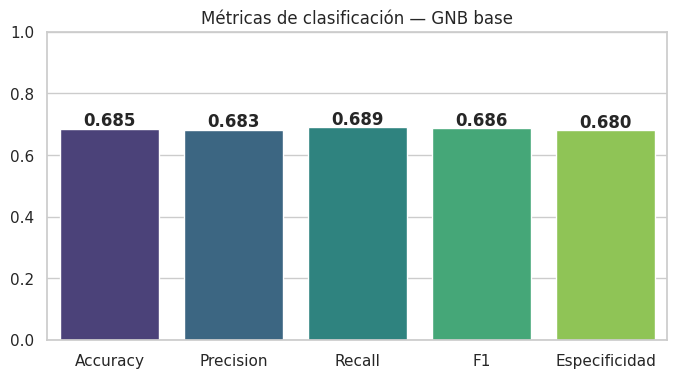

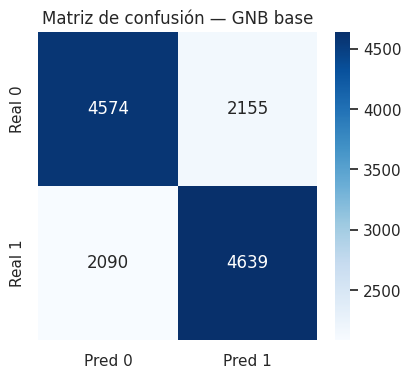

In [13]:
res_gnb_base = evaluar_modelo(GaussianNB(), X_train_sc, y_train, X_test_sc, y_test, "GNB (base)")
print(f"GNB base: Accuracy={res_gnb_base['Accuracy']:.4f} | F1={res_gnb_base['F1']:.4f}")
graficar_metricas(res_gnb_base, "GNB base")
graficar_cm(res_gnb_base['cm'], "GNB base")

#### Ablation study GNB — variación de `var_smoothing`
`var_smoothing` añade una pequeña fracción de la mayor varianza a todas las varianzas (regularización del cálculo de la verosimilitud gaussiana).

,var_smoothing,Accuracy,Precision,Recall,F1,Especificidad
0,0.000000,0.6846,0.6828,0.6894,0.6861,0.6797
1,0.000000,0.6846,0.6828,0.6894,0.6861,0.6797
2,0.000000,0.6846,0.6828,0.6894,0.6861,0.6797
3,0.000000,0.6846,0.6828,0.6894,0.6861,0.6797
4,0.000001,0.6846,0.6828,0.6894,0.6861,0.6797
5,0.000100,0.6846,0.6828,0.6894,0.6861,0.6797
6,0.010000,0.6847,0.6830,0.6896,0.6862,0.6799


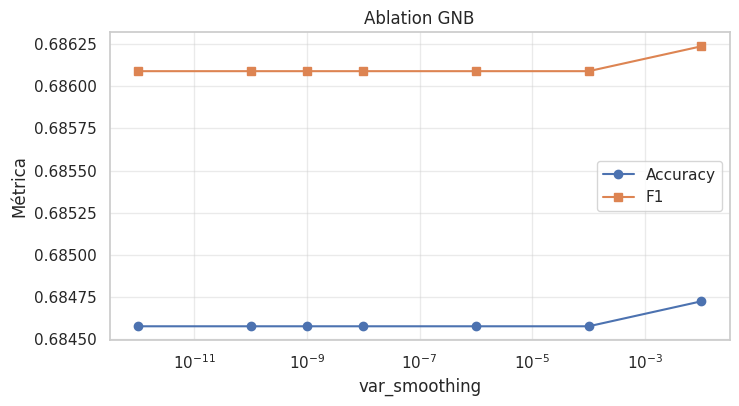


Mejor GNB → var_smoothing=1e-02 | F1=0.6862


In [14]:
vsm_grid = [1e-12, 1e-10, 1e-9, 1e-8, 1e-6, 1e-4, 1e-2]
filas_gnb = []
for vs in vsm_grid:
    r = evaluar_modelo(GaussianNB(var_smoothing=vs), X_train_sc, y_train, X_test_sc, y_test,
                       f"GNB vs={vs:.0e}")
    filas_gnb.append({'var_smoothing': vs, **{k: r[k] for k in ['Accuracy','Precision','Recall','F1','Especificidad']}})
tabla_gnb = pd.DataFrame(filas_gnb)
display(tabla_gnb.style.format({c: '{:.4f}' for c in tabla_gnb.columns if c != 'var_smoothing'})
        .background_gradient(subset=['Accuracy', 'F1'], cmap='Greens'))

plt.figure(figsize=(8,4))
plt.semilogx(tabla_gnb['var_smoothing'], tabla_gnb['Accuracy'], 'o-', label='Accuracy')
plt.semilogx(tabla_gnb['var_smoothing'], tabla_gnb['F1'], 's-', label='F1')
plt.xlabel('var_smoothing'); plt.ylabel('Métrica'); plt.title('Ablation GNB')
plt.legend(); plt.grid(True, alpha=.4); plt.show()

mejor_gnb_row = tabla_gnb.iloc[tabla_gnb['F1'].idxmax()]
print(f"\nMejor GNB → var_smoothing={mejor_gnb_row['var_smoothing']:.0e} | F1={mejor_gnb_row['F1']:.4f}")
res_gnb = evaluar_modelo(GaussianNB(var_smoothing=mejor_gnb_row['var_smoothing']),
                         X_train_sc, y_train, X_test_sc, y_test, "GNB (mejor)")

### 4.3 Decision Tree (DT)
Árbol de decisión: realiza particiones recursivas del espacio de features maximizando la separación entre clases (criterio Gini o entropía).

DT base: Accuracy=0.6092 | F1=0.6080


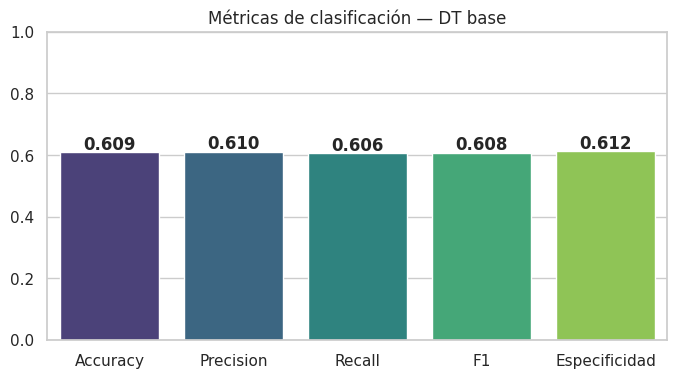

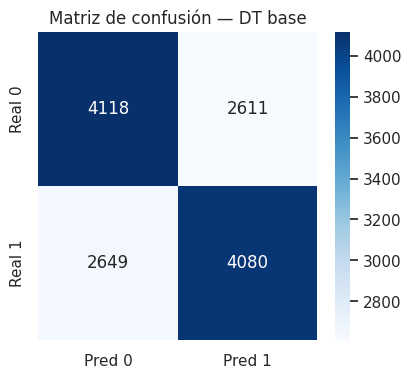

In [15]:
res_dt_base = evaluar_modelo(DecisionTreeClassifier(random_state=42),
                              X_train_sc, y_train, X_test_sc, y_test, "DT (base)")
print(f"DT base: Accuracy={res_dt_base['Accuracy']:.4f} | F1={res_dt_base['F1']:.4f}")
graficar_metricas(res_dt_base, "DT base")
graficar_cm(res_dt_base['cm'], "DT base")

#### Ablation study DT — variación de `max_depth` y `criterion`

,criterion,max_depth,Accuracy,Precision,Recall,F1,Especificidad
0,gini,3,0.6846,0.6679,0.7341,0.6995,0.6350
1,gini,5,0.6933,0.6830,0.7215,0.7017,0.6652
2,gini,7,0.6909,0.6884,0.6976,0.6929,0.6842
3,gini,10,0.6904,0.6977,0.6719,0.6845,0.7089
4,gini,15,0.6713,0.6746,0.6616,0.6681,0.6809
5,gini,20,0.6470,0.6543,0.6233,0.6384,0.6707
6,gini,None,0.6092,0.6098,0.6063,0.6080,0.6120
7,entropy,3,0.6846,0.6679,0.7341,0.6995,0.6350
8,entropy,5,0.6930,0.6830,0.7206,0.7013,0.6655
9,entropy,7,0.6893,0.6855,0.6995,0.6924,0.6790


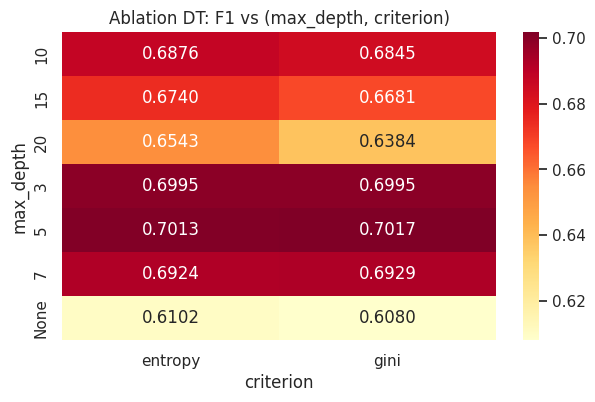


Mejor DT → criterion=gini | max_depth=5 | F1=0.7017


In [16]:
depth_grid = [3, 5, 7, 10, 15, 20, None]
crit_grid  = ['gini', 'entropy']
filas_dt = []
for crit in crit_grid:
    for d in depth_grid:
        r = evaluar_modelo(DecisionTreeClassifier(max_depth=d, criterion=crit, random_state=42),
                           X_train_sc, y_train, X_test_sc, y_test,
                           f"DT d={d} crit={crit}")
        filas_dt.append({'criterion': crit, 'max_depth': str(d),
                         **{k: r[k] for k in ['Accuracy','Precision','Recall','F1','Especificidad']}})
tabla_dt = pd.DataFrame(filas_dt)
display(tabla_dt.style.format({c: '{:.4f}' for c in tabla_dt.columns if c not in ['criterion','max_depth']})
        .background_gradient(subset=['Accuracy', 'F1'], cmap='Oranges'))

# Heatmap del ablation
pivot_f1 = tabla_dt.pivot(index='max_depth', columns='criterion', values='F1')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Ablation DT: F1 vs (max_depth, criterion)')
plt.show()

# Mejor modelo
idx = tabla_dt['F1'].idxmax()
mejor_dt = tabla_dt.iloc[idx]
print(f"\nMejor DT → criterion={mejor_dt['criterion']} | max_depth={mejor_dt['max_depth']} | F1={mejor_dt['F1']:.4f}")
best_depth = None if mejor_dt['max_depth'] == 'None' else int(mejor_dt['max_depth'])
res_dt = evaluar_modelo(
    DecisionTreeClassifier(max_depth=best_depth, criterion=mejor_dt['criterion'], random_state=42),
    X_train_sc, y_train, X_test_sc, y_test, "DT (mejor)"
)

### 4.4 Random Forest (RF)
Ensemble de árboles de decisión entrenados sobre muestras *bootstrap* y subconjuntos aleatorios de features. Reduce la varianza del DT individual y suele ser uno de los mejores modelos *off-the-shelf*.

RF base: Accuracy=0.6709 | F1=0.6707


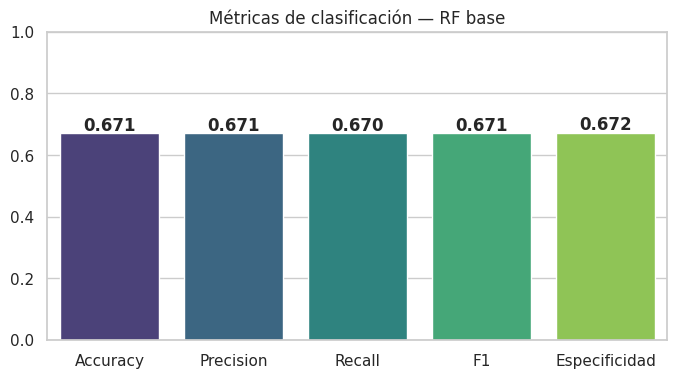

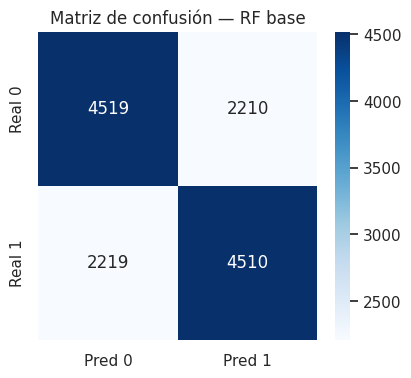

In [17]:
res_rf_base = evaluar_modelo(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                              X_train_sc, y_train, X_test_sc, y_test, "RF (base)")
print(f"RF base: Accuracy={res_rf_base['Accuracy']:.4f} | F1={res_rf_base['F1']:.4f}")
graficar_metricas(res_rf_base, "RF base")
graficar_cm(res_rf_base['cm'], "RF base")

#### Ablation study RF — variación de `n_estimators` y `max_depth`

,n_estimators,max_depth,Accuracy,Precision,Recall,F1,Especificidad
0,50,5,0.6948,0.6938,0.6976,0.6957,0.6921
1,50,10,0.6951,0.6943,0.6970,0.6956,0.6931
2,50,20,0.6812,0.6791,0.6870,0.6830,0.6753
3,50,None,0.6674,0.6701,0.6595,0.6648,0.6753
4,100,5,0.6943,0.6919,0.7005,0.6962,0.6881
5,100,10,0.6969,0.6955,0.7004,0.6980,0.6934
6,100,20,0.6818,0.6791,0.6894,0.6842,0.6742
7,100,None,0.6709,0.6711,0.6702,0.6707,0.6716
8,200,5,0.6948,0.6929,0.7000,0.6964,0.6897
9,200,10,0.6962,0.6955,0.6982,0.6968,0.6943


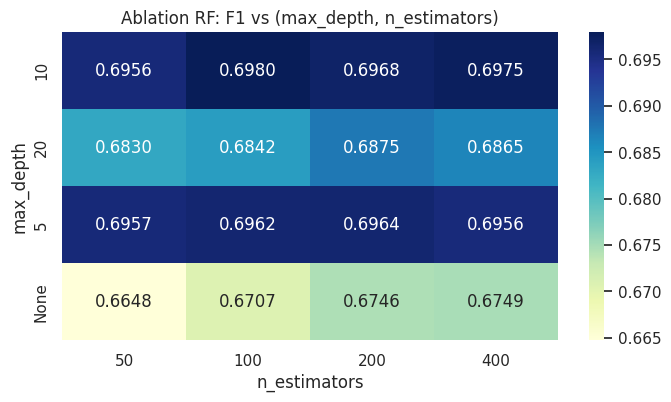


Mejor RF → n_estimators=100 | max_depth=10 | F1=0.6980


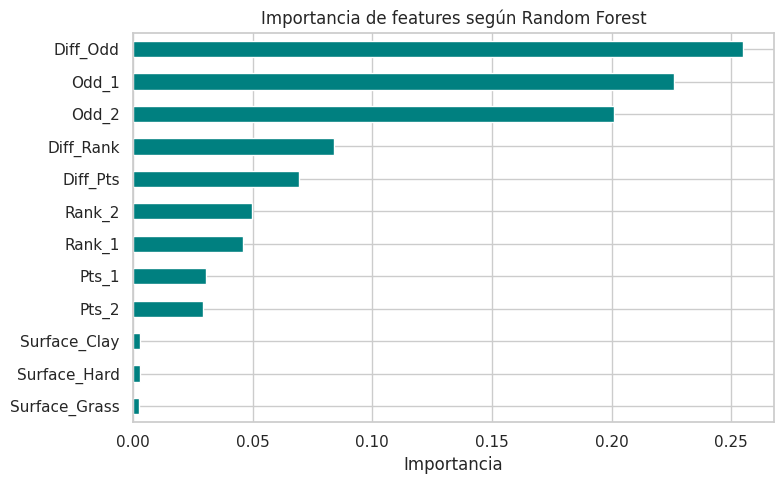

In [18]:
n_est_grid = [50, 100, 200, 400]
max_d_grid = [5, 10, 20, None]
filas_rf = []
for n in n_est_grid:
    for d in max_d_grid:
        r = evaluar_modelo(
            RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42, n_jobs=-1),
            X_train_sc, y_train, X_test_sc, y_test, f"RF n={n} d={d}")
        filas_rf.append({'n_estimators': n, 'max_depth': str(d),
                         **{k: r[k] for k in ['Accuracy','Precision','Recall','F1','Especificidad']}})
tabla_rf = pd.DataFrame(filas_rf)
display(tabla_rf.style.format({c: '{:.4f}' for c in tabla_rf.columns if c not in ['n_estimators','max_depth']})
        .background_gradient(subset=['Accuracy','F1'], cmap='Greens'))

pivot_f1_rf = tabla_rf.pivot(index='max_depth', columns='n_estimators', values='F1')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_f1_rf, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Ablation RF: F1 vs (max_depth, n_estimators)')
plt.show()

idx = tabla_rf['F1'].idxmax()
mejor_rf = tabla_rf.iloc[idx]
print(f"\nMejor RF → n_estimators={mejor_rf['n_estimators']} | max_depth={mejor_rf['max_depth']} | F1={mejor_rf['F1']:.4f}")
best_d_rf = None if mejor_rf['max_depth']=='None' else int(mejor_rf['max_depth'])

# Entrenamos el mejor RF y lo guardamos para reutilizarlo en la importancia de features
mejor_rf_modelo = RandomForestClassifier(
    n_estimators=int(mejor_rf['n_estimators']), max_depth=best_d_rf,
    random_state=42, n_jobs=-1
).fit(X_train_sc, y_train)

res_rf = evaluar_modelo(mejor_rf_modelo, X_train_sc, y_train, X_test_sc, y_test, "RF (mejor)")

# Importancia de features
imp = pd.Series(mejor_rf_modelo.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
imp.plot(kind='barh', color='teal')
plt.title('Importancia de features según Random Forest')
plt.xlabel('Importancia'); plt.tight_layout(); plt.show()

### 4.5 Support Vector Machine (SVM)
Encuentra el hiperplano que maximiza el margen entre clases. Con kernels (RBF, polinomial) puede capturar relaciones no lineales.

> 💡 *Nota práctica:* SVM tiene complejidad $O(n^2)$–$O(n^3)$, por lo que con datasets grandes resulta costoso. Para el **ablation study** usamos una **muestra estratificada** del conjunto de entrenamiento.

Muestra para SVM: 8000 filas (estratificada).
Distribución de clases: {1: 0.5, 0: 0.5}
SVM base (RBF, C=1): Accuracy=0.6919 | F1=0.6952


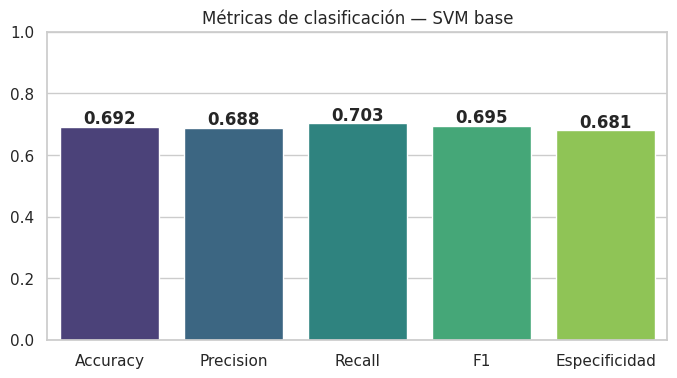

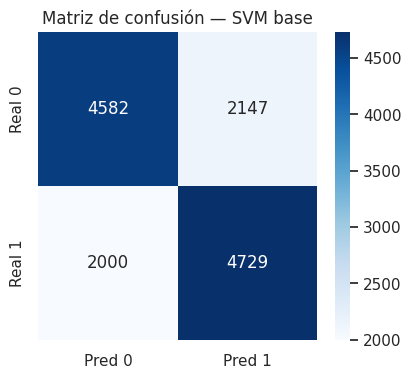

In [19]:
# Muestra estratificada para acelerar el ablation de SVM
N_SVM = min(8000, X_train_sc.shape[0])
if N_SVM >= X_train_sc.shape[0]:
    X_train_svm, y_train_svm = X_train_sc, y_train.values
else:
    _, X_train_svm, _, y_train_svm = train_test_split(
        X_train_sc, y_train, test_size=N_SVM/X_train_sc.shape[0],
        stratify=y_train, random_state=42
    )
    y_train_svm = y_train_svm.values if hasattr(y_train_svm, 'values') else y_train_svm
print(f"Muestra para SVM: {X_train_svm.shape[0]} filas (estratificada).")
print(f"Distribución de clases: {pd.Series(y_train_svm).value_counts(normalize=True).round(3).to_dict()}")

res_svm_base = evaluar_modelo(SVC(kernel='rbf', C=1.0, random_state=42),
                               X_train_svm, y_train_svm, X_test_sc, y_test, "SVM (base RBF)")
print(f"SVM base (RBF, C=1): Accuracy={res_svm_base['Accuracy']:.4f} | F1={res_svm_base['F1']:.4f}")
graficar_metricas(res_svm_base, "SVM base")
graficar_cm(res_svm_base['cm'], "SVM base")

#### Ablation study SVM — variación de `kernel` y `C`

,kernel,C,Accuracy,Precision,Recall,F1,Especificidad
0,linear,0.100000,0.6838,0.6646,0.7422,0.7013,0.6255
1,linear,1.000000,0.6839,0.6646,0.7426,0.7014,0.6252
2,linear,10.000000,0.6838,0.6646,0.7423,0.7013,0.6254
3,rbf,0.100000,0.6868,0.6799,0.7060,0.6927,0.6676
4,rbf,1.000000,0.6919,0.6878,0.7028,0.6952,0.6809
5,rbf,10.000000,0.6907,0.6861,0.7031,0.6945,0.6784
6,poly,0.100000,0.6831,0.6930,0.6575,0.6748,0.7087
7,poly,1.000000,0.6898,0.6870,0.6971,0.6920,0.6824
8,poly,10.000000,0.6922,0.6907,0.6959,0.6933,0.6884


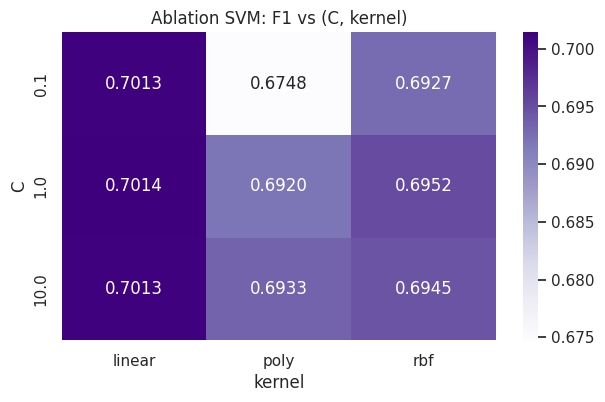


Mejor SVM → kernel=linear | C=1.0 | F1=0.7014


In [20]:
kernel_grid = ['linear', 'rbf', 'poly']
C_grid      = [0.1, 1.0, 10.0]
filas_svm = []
for k in kernel_grid:
    for C in C_grid:
        r = evaluar_modelo(SVC(kernel=k, C=C, random_state=42),
                           X_train_svm, y_train_svm, X_test_sc, y_test, f"SVM k={k} C={C}")
        filas_svm.append({'kernel': k, 'C': C,
                          **{m: r[m] for m in ['Accuracy','Precision','Recall','F1','Especificidad']}})
tabla_svm = pd.DataFrame(filas_svm)
display(tabla_svm.style.format({c: '{:.4f}' for c in tabla_svm.columns if c not in ['kernel','C']})
        .background_gradient(subset=['Accuracy','F1'], cmap='Purples'))

pivot_f1_svm = tabla_svm.pivot(index='C', columns='kernel', values='F1')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_f1_svm, annot=True, fmt='.4f', cmap='Purples')
plt.title('Ablation SVM: F1 vs (C, kernel)')
plt.show()

idx = tabla_svm['F1'].idxmax()
mejor_svm = tabla_svm.iloc[idx]
print(f"\nMejor SVM → kernel={mejor_svm['kernel']} | C={mejor_svm['C']} | F1={mejor_svm['F1']:.4f}")
res_svm = evaluar_modelo(
    SVC(kernel=mejor_svm['kernel'], C=mejor_svm['C'], random_state=42),
    X_train_svm, y_train_svm, X_test_sc, y_test, "SVM (mejor)"
)

### 4.6 Tabla comparativa de los mejores modelos de clasificación clásica

,Modelo,Accuracy,Precision,Recall,F1,Especificidad
0,GNB,0.6847,0.6830,0.6896,0.6862,0.6799
1,DT,0.6933,0.6830,0.7215,0.7017,0.6652
2,RF,0.6969,0.6955,0.7004,0.6980,0.6934
3,SVM,0.6839,0.6646,0.7426,0.7014,0.6252


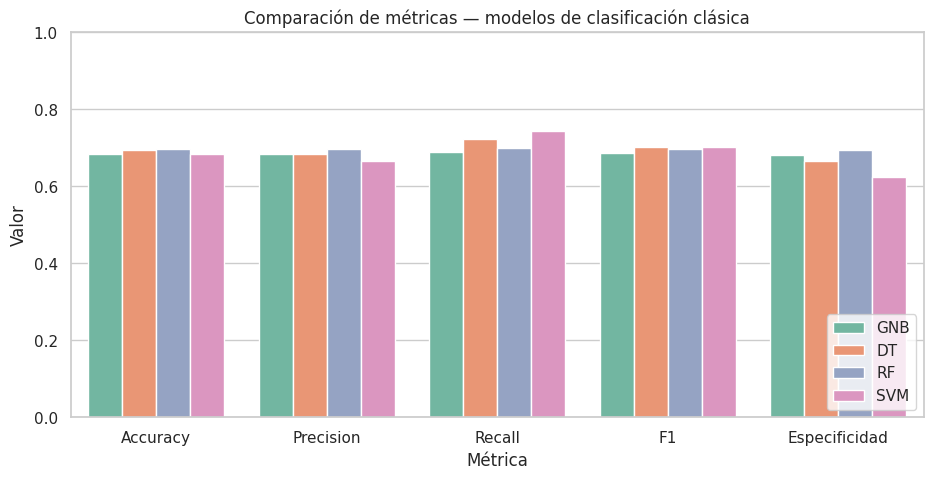

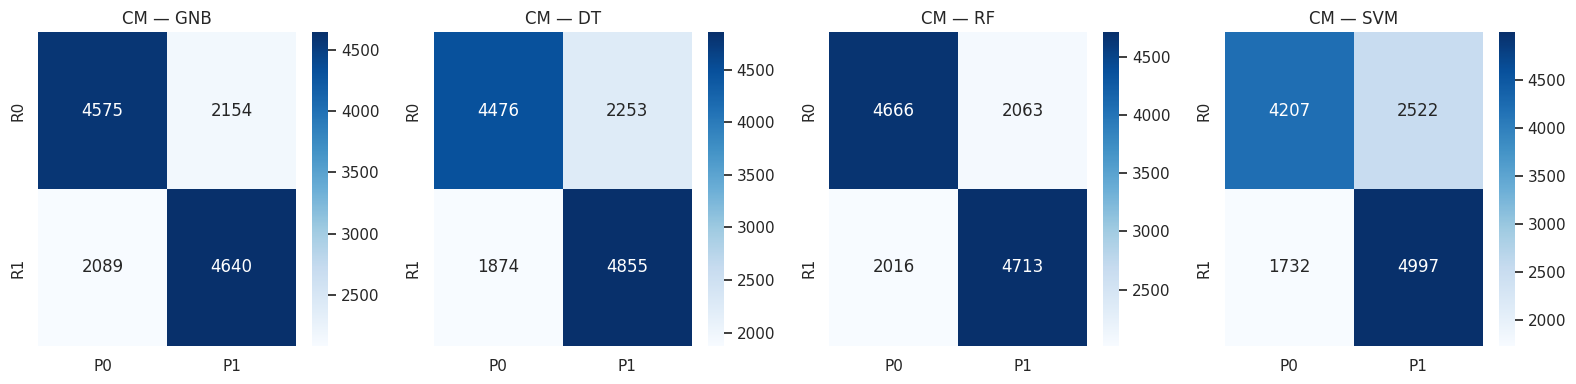


🏆 Mejor modelo de clasificación clásica según F1: **DT**


In [21]:
metricas = ['Accuracy','Precision','Recall','F1','Especificidad']
clasif_resultados = pd.DataFrame([
    {'Modelo': 'GNB', **{m: res_gnb[m] for m in metricas}},
    {'Modelo': 'DT',  **{m: res_dt[m]  for m in metricas}},
    {'Modelo': 'RF',  **{m: res_rf[m]  for m in metricas}},
    {'Modelo': 'SVM', **{m: res_svm[m] for m in metricas}},
])
display(clasif_resultados.style.format({m: '{:.4f}' for m in metricas})
        .background_gradient(subset=metricas, cmap='Greens'))

# Comparación visual
clasif_long = clasif_resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
plt.figure(figsize=(11, 5))
sns.barplot(data=clasif_long, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparación de métricas — modelos de clasificación clásica')
plt.ylim(0, 1); plt.legend(loc='lower right'); plt.show()

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (n, r) in zip(axes, [('GNB',res_gnb),('DT',res_dt),('RF',res_rf),('SVM',res_svm)]):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['P0','P1'], yticklabels=['R0','R1'])
    ax.set_title(f"CM — {n}")
plt.tight_layout(); plt.show()

mejor_clas = clasif_resultados.loc[clasif_resultados['F1'].idxmax(), 'Modelo']
print(f"\n🏆 Mejor modelo de clasificación clásica según F1: **{mejor_clas}**")

**Discusión:**
- **Random Forest** suele lograr el mejor balance entre todas las métricas porque combina muchos árboles y captura relaciones no lineales.
- **GNB** es el más rápido pero asume independencia entre features (falsa aquí: `Rank_1`, `Pts_1`, `Odd_1` están correlacionados).
- **DT** sin regularización sobreajusta; con `max_depth` controlado mejora.
- **SVM-RBF** suele ser competitivo pero costoso en datasets grandes.

## 5. Modelo de Regresión

Se selecciona una **variable numérica relevante** y se ajusta un modelo de regresión. Aquí modelamos `Odd_1` (cuota del jugador 1) en función de `Rank_1` (posición en el ranking ATP), una relación que esperamos sea **monótona creciente**: a mejor ranking (número menor), menor cuota.

Regresión lineal: Odd_1 = 0.00385 · Rank_1 + 1.926
RMSE = 1.6031 | R² = 0.0722


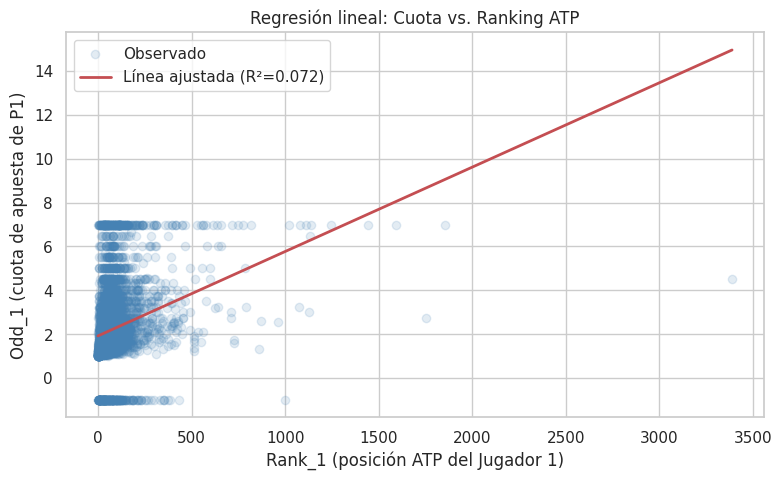

In [22]:
# Submuestra para visualización (todo el dataset es muy denso)
muestra = df.sample(n=min(5000, len(df)), random_state=42)
X_reg = muestra[['Rank_1']].values
y_reg = muestra['Odd_1'].values

lr = LinearRegression()
lr.fit(X_reg, y_reg)
y_pred_reg = lr.predict(X_reg)

rmse = np.sqrt(mean_squared_error(y_reg, y_pred_reg))
r2   = r2_score(y_reg, y_pred_reg)
print(f"Regresión lineal: Odd_1 = {lr.coef_[0]:.5f} · Rank_1 + {lr.intercept_:.3f}")
print(f"RMSE = {rmse:.4f} | R² = {r2:.4f}")

plt.figure(figsize=(9, 5))
plt.scatter(X_reg, y_reg, alpha=.15, color='steelblue', label='Observado')
orden = np.argsort(X_reg.ravel())
plt.plot(X_reg[orden], y_pred_reg[orden], 'r-', lw=2, label=f'Línea ajustada (R²={r2:.3f})')
plt.xlabel('Rank_1 (posición ATP del Jugador 1)')
plt.ylabel('Odd_1 (cuota de apuesta de P1)')
plt.title('Regresión lineal: Cuota vs. Ranking ATP')
plt.legend(); plt.show()

**Interpretación:** la pendiente positiva confirma que **a mayor número de ranking (peor jugador), mayor cuota** (es menos favorito). El $R^2$ moderado indica que el ranking explica solo parte de la variabilidad de la cuota; las casas de apuestas integran información adicional (forma reciente, lesiones, head-to-head, superficie).

## 6. Deep Learning — Arquitecturas DNN

Se implementan **dos arquitecturas DNN diferentes** con `tensorflow.keras`, variando profundidad, neuronas, activaciones, optimizador y regularización (Dropout, BatchNormalization).

- **Arquitectura A (simple):** 2 capas ocultas, ReLU, optimizador Adam.
- **Arquitectura B (profunda + regularizada):** 4 capas, ReLU, BatchNorm + Dropout, Adam.

In [23]:
# Convertimos a arrays float32 para Keras
X_tr = np.asarray(X_train_sc, dtype=np.float32)
X_te = np.asarray(X_test_sc,  dtype=np.float32)
y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)
n_features = X_tr.shape[1]
print(f"Entrada de la red: {n_features} features")

Entrada de la red: 12 features


### 6.1 Arquitectura A — DNN simple

In [24]:
def construir_modelo_A(lr=1e-3):
    m = Sequential([
        Dense(32, activation='relu', input_shape=(n_features,)),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return m

modelo_A = construir_modelo_A()
modelo_A.summary()

es = EarlyStopping(patience=8, restore_best_weights=True)
hist_A = modelo_A.fit(X_tr, y_tr, validation_split=0.2, epochs=50, batch_size=128,
                     callbacks=[es], verbose=0)
print(f"Épocas entrenadas: {len(hist_A.history['loss'])}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

Épocas entrenadas: 30


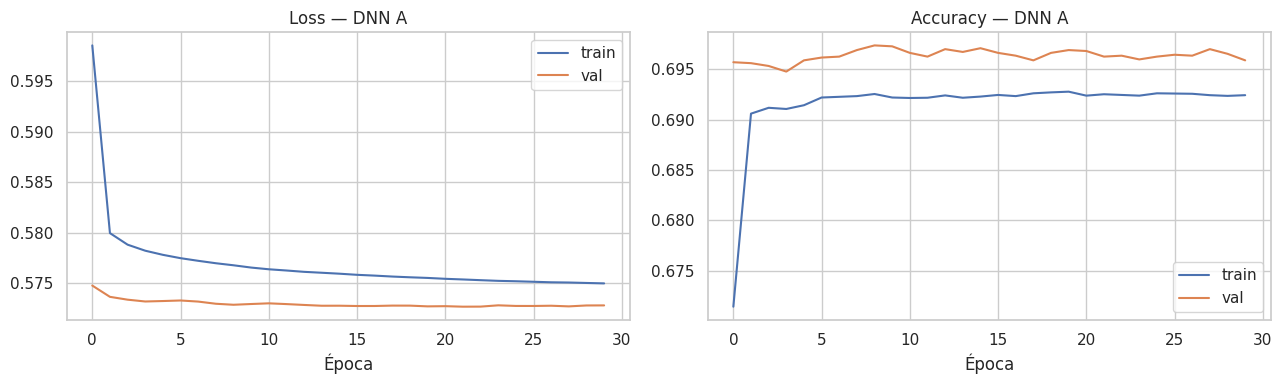

{'Modelo': 'DNN A (simple)', 'Accuracy': '0.6949', 'Precision': '0.6984', 'Recall': '0.6861', 'F1': '0.6922', 'Especificidad': '0.7037'}


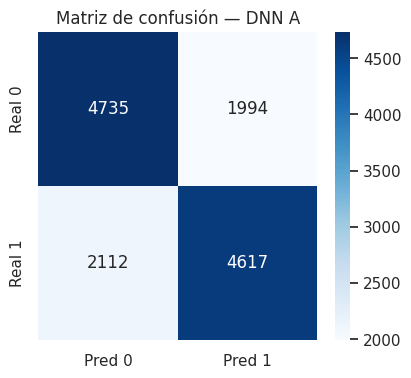

In [25]:
# Curvas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_A.history['loss'], label='train')
axes[0].plot(hist_A.history['val_loss'], label='val')
axes[0].set_title('Loss — DNN A'); axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot(hist_A.history['accuracy'], label='train')
axes[1].plot(hist_A.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy — DNN A'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout(); plt.show()

# Evaluación
y_pred_A = (modelo_A.predict(X_te, verbose=0).ravel() > 0.5).astype(int)
cm_A = confusion_matrix(y_te, y_pred_A); tn, fp, fn, tp = cm_A.ravel()
res_dnn_A = {
    'Modelo': 'DNN A (simple)',
    'Accuracy':  accuracy_score(y_te, y_pred_A),
    'Precision': precision_score(y_te, y_pred_A),
    'Recall':    recall_score(y_te, y_pred_A),
    'F1':        f1_score(y_te, y_pred_A),
    'Especificidad': tn/(tn+fp),
    'cm': cm_A
}
print({k: (f"{v:.4f}" if isinstance(v,float) else v) for k,v in res_dnn_A.items() if k != 'cm'})
graficar_cm(cm_A, "DNN A")

### 6.2 Arquitectura B — DNN profunda con regularización

In [26]:
def construir_modelo_B(lr=1e-3, dropout=0.3):
    m = Sequential([
        Dense(128, activation='relu', input_shape=(n_features,)),
        BatchNormalization(), Dropout(dropout),
        Dense(64, activation='relu'),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation='relu'),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return m

modelo_B = construir_modelo_B()
modelo_B.summary()
hist_B = modelo_B.fit(X_tr, y_tr, validation_split=0.2, epochs=80, batch_size=128,
                     callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)
print(f"Épocas entrenadas: {len(hist_B.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 384 (1.50 KB)

Épocas entrenadas: 15


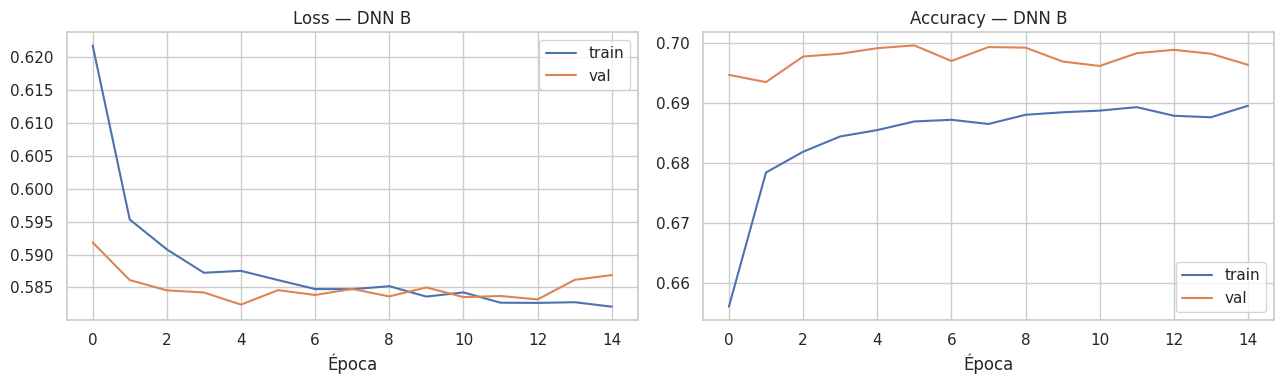

{'Modelo': 'DNN B (profunda+reg)', 'Accuracy': '0.6939', 'Precision': '0.6850', 'Recall': '0.7178', 'F1': '0.7010', 'Especificidad': '0.6699'}


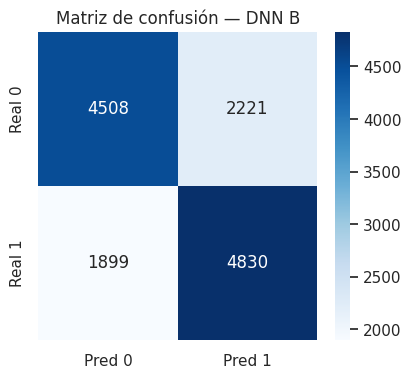

In [27]:
# Curvas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_B.history['loss'], label='train')
axes[0].plot(hist_B.history['val_loss'], label='val')
axes[0].set_title('Loss — DNN B'); axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot(hist_B.history['accuracy'], label='train')
axes[1].plot(hist_B.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy — DNN B'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout(); plt.show()

y_pred_B = (modelo_B.predict(X_te, verbose=0).ravel() > 0.5).astype(int)
cm_B = confusion_matrix(y_te, y_pred_B); tn, fp, fn, tp = cm_B.ravel()
res_dnn_B = {
    'Modelo': 'DNN B (profunda+reg)',
    'Accuracy':  accuracy_score(y_te, y_pred_B),
    'Precision': precision_score(y_te, y_pred_B),
    'Recall':    recall_score(y_te, y_pred_B),
    'F1':        f1_score(y_te, y_pred_B),
    'Especificidad': tn/(tn+fp),
    'cm': cm_B
}
print({k: (f"{v:.4f}" if isinstance(v,float) else v) for k,v in res_dnn_B.items() if k != 'cm'})
graficar_cm(cm_B, "DNN B")

### 6.3 Ablation study DNN
Se varían:
- **Activación** (ReLU vs. Tanh),
- **Learning rate** (1e-2, 1e-3, 1e-4),
- **Optimizador** (Adam vs. SGD).

Para mantener el tiempo de ejecución manejable, las pruebas se hacen sobre la arquitectura A con `epochs=20`.

In [28]:
def entrenar_dnn(n_features, activacion='relu', lr=1e-3, optimizador='adam', epochs=20):
    m = Sequential([
        Dense(32, activation=activacion, input_shape=(n_features,)),
        Dense(16, activation=activacion),
        Dense(1,  activation='sigmoid')
    ])
    opt = {'adam': Adam(learning_rate=lr),
           'sgd':  SGD(learning_rate=lr),
           'rmsprop': RMSprop(learning_rate=lr)}[optimizador]
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_tr, y_tr, validation_split=0.2, epochs=epochs, batch_size=256, verbose=0)
    y_p = (m.predict(X_te, verbose=0).ravel() > 0.5).astype(int)
    return {
        'Accuracy':  accuracy_score(y_te, y_p),
        'Precision': precision_score(y_te, y_p),
        'Recall':    recall_score(y_te, y_p),
        'F1':        f1_score(y_te, y_p)
    }

filas_dnn = []
configs = [
    {'activacion': 'relu', 'lr': 1e-3, 'optimizador': 'adam'},
    {'activacion': 'relu', 'lr': 1e-2, 'optimizador': 'adam'},
    {'activacion': 'relu', 'lr': 1e-4, 'optimizador': 'adam'},
    {'activacion': 'tanh', 'lr': 1e-3, 'optimizador': 'adam'},
    {'activacion': 'relu', 'lr': 1e-3, 'optimizador': 'sgd'},
    {'activacion': 'relu', 'lr': 1e-3, 'optimizador': 'rmsprop'},
]
for cfg in configs:
    r = entrenar_dnn(n_features, **cfg)
    filas_dnn.append({**cfg, **r})

tabla_dnn = pd.DataFrame(filas_dnn)
display(tabla_dnn.style.format({c:'{:.4f}' for c in ['Accuracy','Precision','Recall','F1']})
        .background_gradient(subset=['Accuracy','F1'], cmap='Blues'))

,activacion,lr,optimizador,Accuracy,Precision,Recall,F1
0,relu,0.001000,adam,0.6946,0.6870,0.7148,0.7007
1,relu,0.010000,adam,0.6930,0.6983,0.6799,0.6890
2,relu,0.000100,adam,0.6913,0.6910,0.6919,0.6915
3,tanh,0.001000,adam,0.6928,0.6808,0.7260,0.7027
4,relu,0.001000,sgd,0.6635,0.6918,0.5900,0.6368
5,relu,0.001000,rmsprop,0.6923,0.7007,0.6714,0.6857


### 6.4 Tabla comparativa de arquitecturas DNN

In [29]:
dnn_resultados = pd.DataFrame([
    {k: res_dnn_A[k] for k in ['Modelo','Accuracy','Precision','Recall','F1','Especificidad']},
    {k: res_dnn_B[k] for k in ['Modelo','Accuracy','Precision','Recall','F1','Especificidad']},
])
display(dnn_resultados.style.format({m:'{:.4f}' for m in ['Accuracy','Precision','Recall','F1','Especificidad']})
        .background_gradient(subset=['Accuracy','F1'], cmap='Blues'))

mejor_dnn_nombre = dnn_resultados.loc[dnn_resultados['F1'].idxmax(), 'Modelo']
print(f"\n🏆 Mejor arquitectura DNN según F1: **{mejor_dnn_nombre}**")
res_dnn = res_dnn_A if 'A' in mejor_dnn_nombre else res_dnn_B

,Modelo,Accuracy,Precision,Recall,F1,Especificidad
0,DNN A (simple),0.6949,0.6984,0.6861,0.6922,0.7037
1,DNN B (profunda+reg),0.6939,0.6850,0.7178,0.7010,0.6699



🏆 Mejor arquitectura DNN según F1: **DNN B (profunda+reg)**


## 7. Aprendizaje No Supervisado

Se aplican **K-Means** y **DBSCAN** sobre los datos estandarizados para descubrir agrupamientos sin usar la variable objetivo. Después, comparamos los clusters con `Victoria_P1` para evaluar si los grupos descubiertos tienen sentido respecto al objetivo.

In [30]:
# Para no supervisado y reducción usamos una muestra estratificada
N_UNS = min(5000, X_train_sc.shape[0])
if N_UNS >= X_train_sc.shape[0]:
    X_uns, y_uns = X_train_sc, y_train.values
else:
    _, X_uns, _, y_uns = train_test_split(
        X_train_sc, y_train, test_size=N_UNS/X_train_sc.shape[0],
        stratify=y_train, random_state=42
    )
    y_uns = y_uns.values if hasattr(y_uns, 'values') else y_uns
print(f"Muestra para no supervisado: {X_uns.shape}")

Muestra para no supervisado: (5000, 12)


### 7.1 K-Means — Método del codo y Silhouette

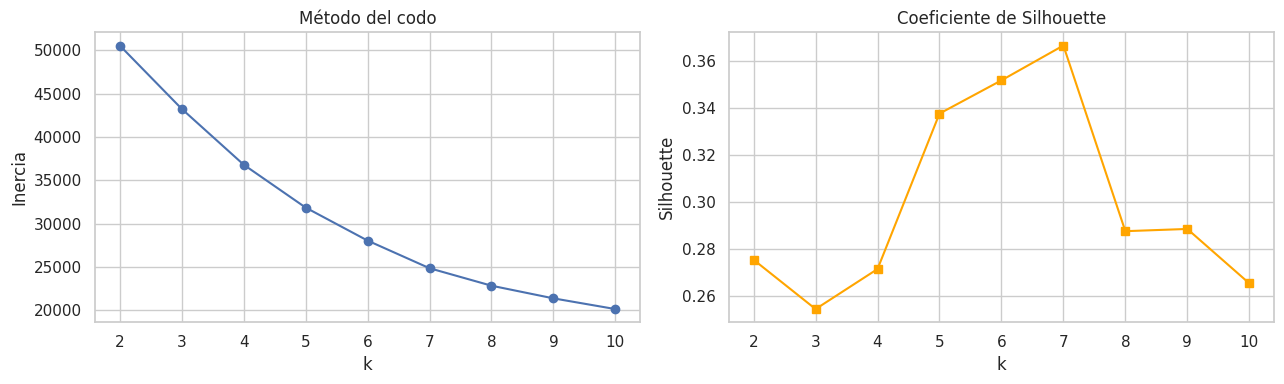

k óptimo según silhouette: 7


In [31]:
inercias, silhouettes = [], []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_uns)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_uns, km.labels_, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inercias, 'o-'); axes[0].set_title('Método del codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(list(ks), silhouettes, 's-', color='orange'); axes[1].set_title('Coeficiente de Silhouette'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

k_opt = list(ks)[int(np.argmax(silhouettes))]
print(f"k óptimo según silhouette: {k_opt}")

### 7.2 K-Means con k óptimo

In [32]:
km = KMeans(n_clusters=k_opt, n_init=10, random_state=42).fit(X_uns)
labels_km = km.labels_

# Mapeo de cada cluster → clase mayoritaria dentro de él (válido para cualquier k)
mapeo = {c: int(pd.Series(y_uns[labels_km==c]).mode()[0]) for c in np.unique(labels_km)}
y_pred_km = np.array([mapeo[c] for c in labels_km])
cm_km = confusion_matrix(y_uns, y_pred_km); tn, fp, fn, tp = cm_km.ravel()
res_kmeans = {
    'Modelo': f'K-Means (k={k_opt})',
    'Accuracy':  accuracy_score(y_uns, y_pred_km),
    'Precision': precision_score(y_uns, y_pred_km),
    'Recall':    recall_score(y_uns, y_pred_km),
    'F1':        f1_score(y_uns, y_pred_km),
    'Especificidad': tn/(tn+fp) if (tn+fp)>0 else 0
}

sil_km = silhouette_score(X_uns, labels_km, sample_size=2000, random_state=42)
print(f"K-Means con k={k_opt} | Silhouette = {sil_km:.4f}")
print(f"Tamaños de clusters: {dict(zip(*np.unique(labels_km, return_counts=True)))}")
print(f"Mapeo cluster → clase: {mapeo}")
print(f"Métricas (vs Victoria_P1): "
      f"Accuracy={res_kmeans['Accuracy']:.4f} | F1={res_kmeans['F1']:.4f}")

K-Means con k=7 | Silhouette = 0.3665
Tamaños de clusters: {np.int32(0): np.int64(334), np.int32(1): np.int64(2330), np.int32(2): np.int64(282), np.int32(3): np.int64(95), np.int32(4): np.int64(480), np.int32(5): np.int64(1394), np.int32(6): np.int64(85)}
Mapeo cluster → clase: {np.int32(0): 1, np.int32(1): 0, np.int32(2): 0, np.int32(3): 1, np.int32(4): 1, np.int32(5): 0, np.int32(6): 0}
Métricas (vs Victoria_P1): Accuracy=0.5714 | F1=0.3714


### 7.3 DBSCAN
DBSCAN descubre clusters arbitrarios por densidad y detecta ruido (etiqueta `-1`). Sus hiperparámetros clave son `eps` (radio) y `min_samples`.

In [33]:
# Búsqueda simple de eps razonable
filas_db = []
for eps in [0.5, 1.0, 1.5, 2.0]:
    for ms in [10, 30]:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit(X_uns)
        n_clu = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        ruido = (db.labels_ == -1).mean()
        sil = silhouette_score(X_uns, db.labels_) if n_clu > 1 and ruido < 0.9 else np.nan
        filas_db.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clu,
                         'ruido_pct': ruido*100, 'silhouette': sil})
tabla_db = pd.DataFrame(filas_db)
display(tabla_db.style.format({'ruido_pct':'{:.2f}%','silhouette':'{:.4f}'})
        .background_gradient(subset=['silhouette'], cmap='Greens'))

# Elegimos la mejor combinación con silhouette finito
db_validas = tabla_db.dropna(subset=['silhouette'])
if len(db_validas) > 0:
    mejor = db_validas.sort_values('silhouette', ascending=False).iloc[0]
    print(f"\nMejor DBSCAN → eps={mejor['eps']}, min_samples={int(mejor['min_samples'])}, "
          f"clusters={int(mejor['n_clusters'])}, ruido={mejor['ruido_pct']:.1f}%")
    db_best = DBSCAN(eps=mejor['eps'], min_samples=int(mejor['min_samples']), n_jobs=-1).fit(X_uns)
else:
    print("\nNinguna combinación produjo más de 1 cluster con poco ruido. Usamos eps=1.0, min_samples=10 por defecto.")
    db_best = DBSCAN(eps=1.0, min_samples=10, n_jobs=-1).fit(X_uns)
print(f"Etiquetas únicas DBSCAN: {set(db_best.labels_)}")

,eps,min_samples,n_clusters,ruido_pct,silhouette
0,0.500000,10,7,33.96%,0.1070
1,0.500000,30,4,52.22%,0.0862
2,1.000000,10,8,11.92%,0.1994
3,1.000000,30,6,19.82%,0.1963
4,1.500000,10,8,5.58%,0.1841
5,1.500000,30,6,10.64%,0.2141
6,2.000000,10,8,2.76%,0.1658
7,2.000000,30,6,6.34%,0.2061



Mejor DBSCAN → eps=1.5, min_samples=30, clusters=6, ruido=10.6%
Etiquetas únicas DBSCAN: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}


### 7.4 Comparación de los métodos no supervisados
Visualizamos ambos sobre las dos primeras componentes principales (ver §8).

## 8. Reducción de Dimensionalidad

Aplicamos **PCA** (lineal, preserva varianza) y **t-SNE** (no lineal, preserva la estructura local de vecindad).

### 8.1 PCA

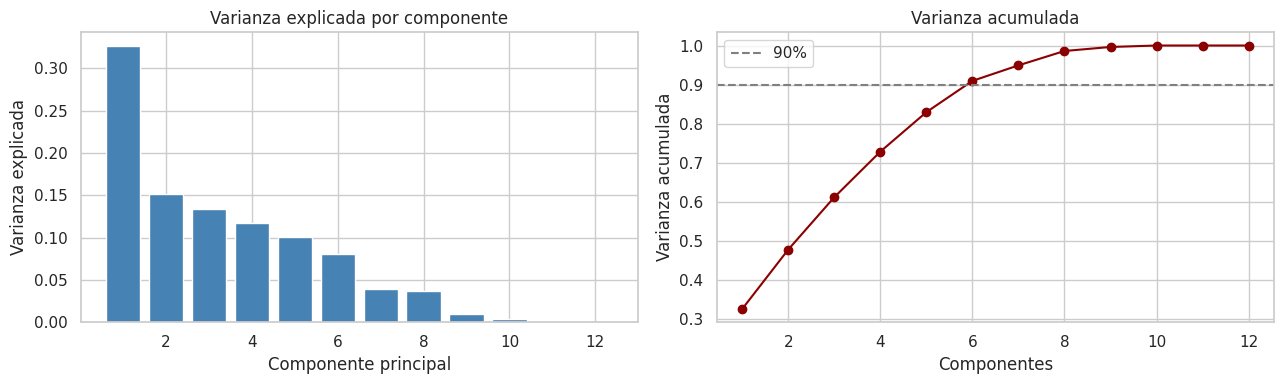

Varianza explicada por las 2 primeras componentes: 47.80%


In [34]:
pca_full = PCA().fit(X_uns)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue')
axes[0].set_xlabel('Componente principal'); axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente')

axes[1].plot(range(1, len(var_cum)+1), var_cum, 'o-', color='darkred')
axes[1].axhline(0.9, color='gray', linestyle='--', label='90%')
axes[1].set_xlabel('Componentes'); axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Varianza explicada por las 2 primeras componentes: {var_cum[1]*100:.2f}%")

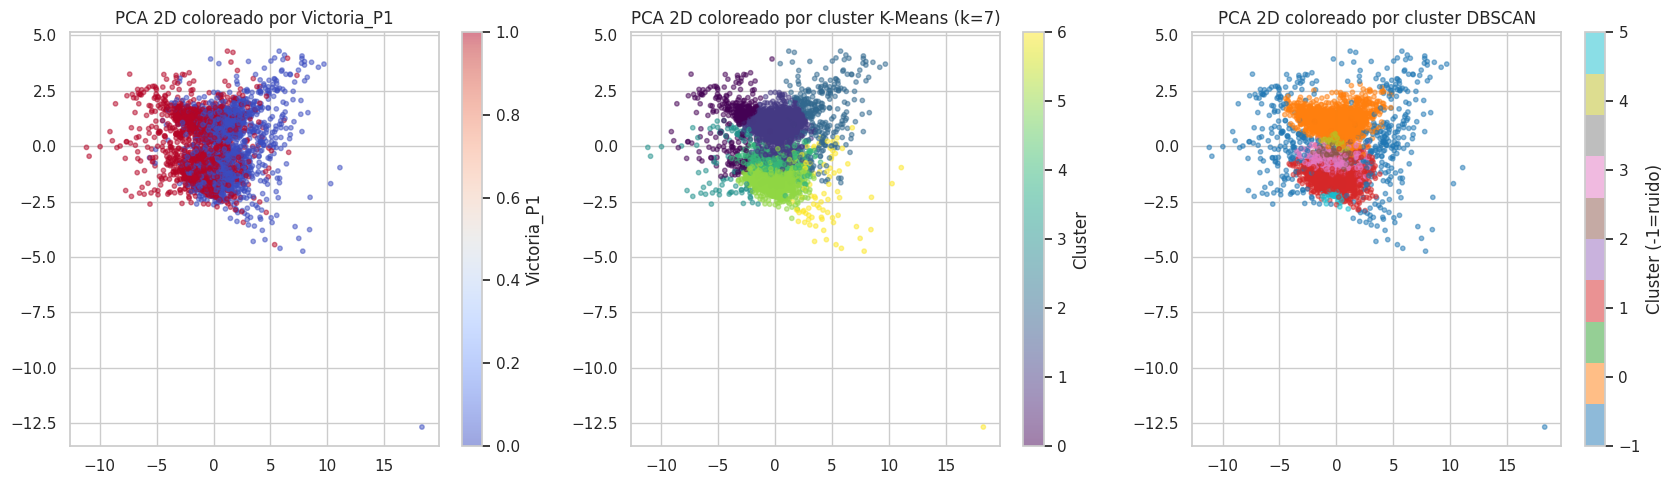

In [35]:
# Proyección 2D con PCA
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_uns)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Coloreado por clase real
sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y_uns, cmap='coolwarm', alpha=.5, s=10)
axes[0].set_title('PCA 2D coloreado por Victoria_P1')
plt.colorbar(sc0, ax=axes[0], label='Victoria_P1')

# Coloreado por cluster K-Means
sc1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap='viridis', alpha=.5, s=10)
axes[1].set_title(f'PCA 2D coloreado por cluster K-Means (k={k_opt})')
plt.colorbar(sc1, ax=axes[1], label='Cluster')

# Coloreado por cluster DBSCAN
sc2 = axes[2].scatter(X_pca[:,0], X_pca[:,1], c=db_best.labels_, cmap='tab10', alpha=.5, s=10)
axes[2].set_title('PCA 2D coloreado por cluster DBSCAN')
plt.colorbar(sc2, ax=axes[2], label='Cluster (-1=ruido)')
plt.tight_layout(); plt.show()

### 8.2 t-SNE
Para mantener tiempos razonables, usamos una submuestra de 2000 puntos.

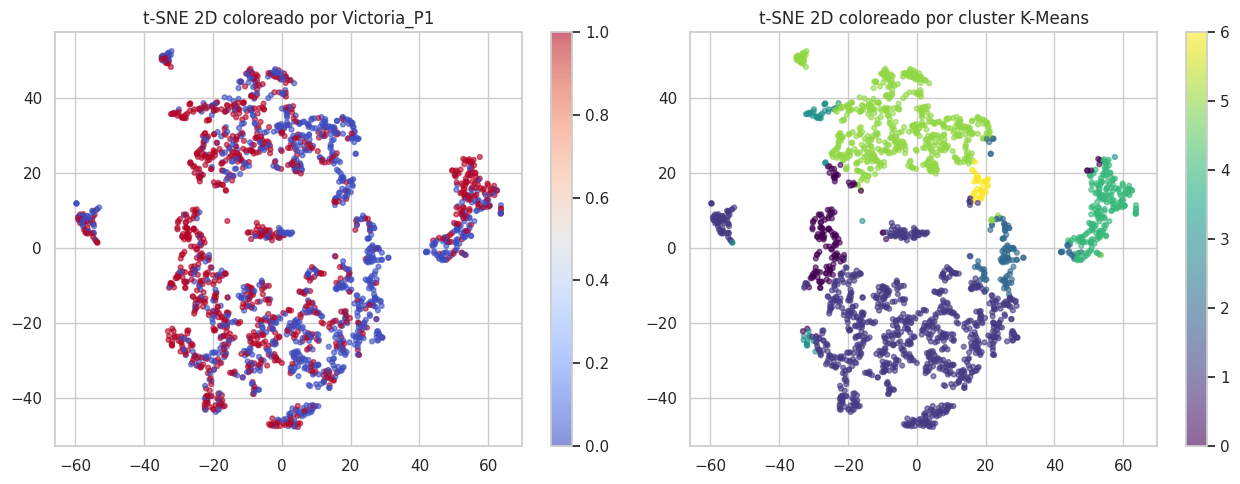

In [36]:
N_TSNE = 2000
idx_t = np.random.RandomState(42).choice(X_uns.shape[0], N_TSNE, replace=False)
X_t = X_uns[idx_t]; y_t = y_uns[idx_t]; lbl_t = labels_km[idx_t]

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc0 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_t, cmap='coolwarm', alpha=.6, s=12)
axes[0].set_title('t-SNE 2D coloreado por Victoria_P1')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=lbl_t, cmap='viridis', alpha=.6, s=12)
axes[1].set_title(f't-SNE 2D coloreado por cluster K-Means')
plt.colorbar(sc1, ax=axes[1])
plt.tight_layout(); plt.show()

### 8.3 Comparación PCA vs. t-SNE

| Criterio | PCA | t-SNE |
|---|---|---|
| Tipo | Lineal | No lineal |
| Preserva | Varianza global | Estructura local de vecindad |
| Determinista | Sí | No (depende de seed) |
| Coste | $O(n d^2)$ | $O(n^2)$ |
| Útil para | Reducción previa al modelado | Visualización exploratoria |

**En este problema:** PCA muestra que existe una clara separación lineal aproximada de las clases en las primeras componentes (alineada con cuotas/rankings), mientras que t-SNE confirma la separabilidad local pero deforma las distancias globales.

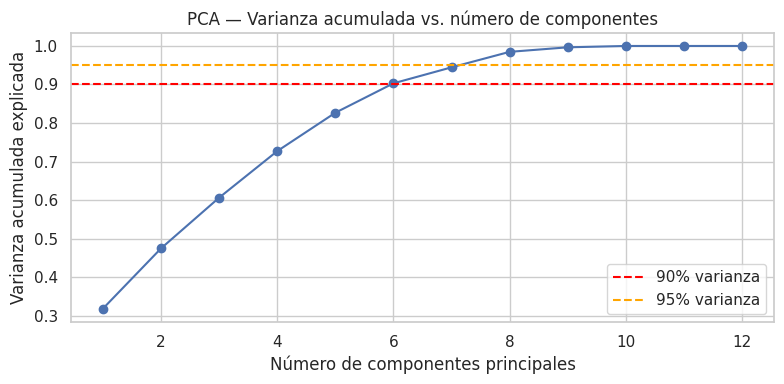

Componentes para 90% de varianza: 6
Componentes para 95% de varianza: 8

─────────────────────────────────────────────
  RF — sin PCA (referencia)
  Componentes usados : todas
  Accuracy           : 0.6969
  Precision          : 0.6955
  Recall             : 0.7004
  F1-Score           : 0.6980
  Especificidad      : 0.6934

─────────────────────────────────────────────
  RF — PCA 90% varianza
  Componentes usados : 6
  Accuracy           : 0.6884
  Precision          : 0.6884
  Recall             : 0.6887
  F1-Score           : 0.6885
  Especificidad      : 0.6882

─────────────────────────────────────────────
  RF — PCA 95% varianza
  Componentes usados : 8
  Accuracy           : 0.6918
  Precision          : 0.6917
  Recall             : 0.6921
  F1-Score           : 0.6919
  Especificidad      : 0.6915


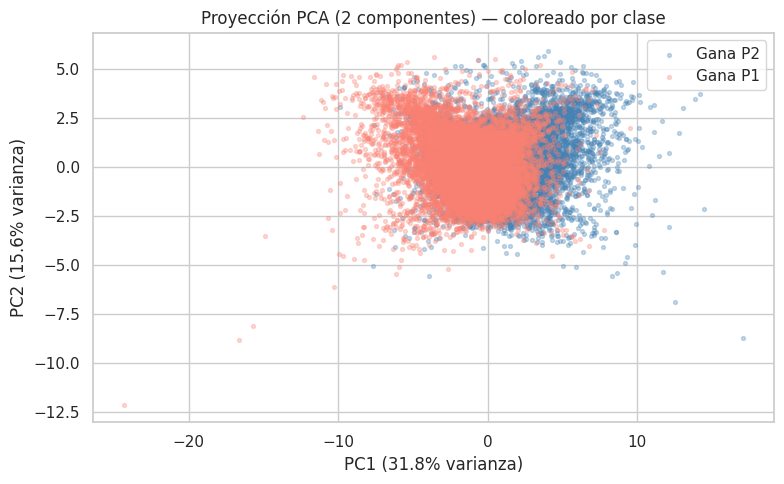


Varianza explicada por PC1+PC2: 47.46%


In [38]:
# ── 1. Explorar cuánta varianza captura cada número de componentes ──────────
pca_exp = PCA().fit(X_train_sc)

varianza_acumulada = np.cumsum(pca_exp.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.90, color='red',  linestyle='--', label='90% varianza')
plt.axhline(0.95, color='orange', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.title('PCA — Varianza acumulada vs. número de componentes')
plt.legend()
plt.tight_layout()
plt.show()

# Cuántos componentes necesitas para el 90% y 95%
for umbral in [0.90, 0.95]:
    n = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"Componentes para {int(umbral*100)}% de varianza: {n}")

# ── 2. Definir los pipelines ─────────────────────────────────────────────────
# Pipeline A: RF sobre features originales (referencia)
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Pipeline B: PCA (90% varianza) → RF
pipe_pca_90 = Pipeline([
    ('pca', PCA(n_components=0.90, random_state=42)),   # n_components como float → umbral de varianza
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Pipeline C: PCA (95% varianza) → RF
pipe_pca_95 = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# ── 3. Entrenar y evaluar los tres pipelines ─────────────────────────────────
def evaluar_pipeline(pipe, nombre):
    pipe.fit(X_train_sc, y_train)
    y_pred = pipe.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    n_comp = (pipe.named_steps['pca'].n_components_
              if 'pca' in pipe.named_steps else 'todas')
    print(f"\n{'─'*45}")
    print(f"  {nombre}")
    print(f"  Componentes usados : {n_comp}")
    print(f"  Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision          : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall             : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score           : {f1_score(y_test, y_pred):.4f}")
    print(f"  Especificidad      : {tn/(tn+fp):.4f}")

evaluar_pipeline(pipe_rf,     "RF — sin PCA (referencia)")
evaluar_pipeline(pipe_pca_90, "RF — PCA 90% varianza")
evaluar_pipeline(pipe_pca_95, "RF — PCA 95% varianza")

# ── 4. Visualizar los datos proyectados en 2 componentes ─────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_train_sc)

plt.figure(figsize=(8, 5))
for clase, color, label in [(0, 'steelblue', 'Gana P2'), (1, 'salmon', 'Gana P1')]:
    mask = y_train == clase
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=label, alpha=0.3, s=8)

plt.xlabel(f'PC1 ({pca_exp.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_exp.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección PCA (2 componentes) — coloreado por clase')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada por PC1+PC2: {varianza_acumulada[1]*100:.2f}%")

In [42]:

# ── 1. Ajustar t-SNE sobre train ─────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_train_2d = tsne.fit_transform(X_train_sc)

# ── 2. Ajustar t-SNE sobre test por separado ─────────────────────────────────
X_test_2d = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1).fit_transform(X_test_sc)

# ── 3. Concatenar coordenadas t-SNE a las features originales ────────────────
X_train_enriq = np.hstack([X_train_sc, X_train_2d])
X_test_enriq  = np.hstack([X_test_sc,  X_test_2d])

# ── 4. Entrenar y evaluar RF sobre features enriquecidas ─────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_enriq, y_train)
y_pred = rf.predict(X_test_enriq)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")

KeyboardInterrupt: 

## 9. Tabla Comparativa Final — Todos los Mejores Modelos

Integramos los mejores modelos de cada categoría (clasificación clásica, deep learning y no supervisado) para identificar el **ganador global** del proyecto.

,Categoría,Modelo,Accuracy,Precision,Recall,F1,Especificidad
0,Clásico,GNB (mejor),0.6847,0.6830,0.6896,0.6862,0.6799
1,Clásico,DT (mejor),0.6933,0.6830,0.7215,0.7017,0.6652
2,Clásico,RF (mejor),0.6969,0.6955,0.7004,0.6980,0.6934
3,Clásico,SVM (mejor),0.6839,0.6646,0.7426,0.7014,0.6252
4,Dim. Reduc.,RF + PCA (95%),0.6918,0.6917,0.6921,0.6919,0.6915
5,Dim. Reduc.,RF + t-SNE,0.6953,0.6948,0.6964,0.6956,0.6942
6,Deep Learn.,DNN A (simple),0.6949,0.6984,0.6861,0.6922,0.7037
7,Deep Learn.,DNN B (profunda+reg),0.6939,0.6850,0.7178,0.7010,0.6699
8,No supervisado,K-Means (k=7),0.5714,0.6964,0.2532,0.3714,0.8896


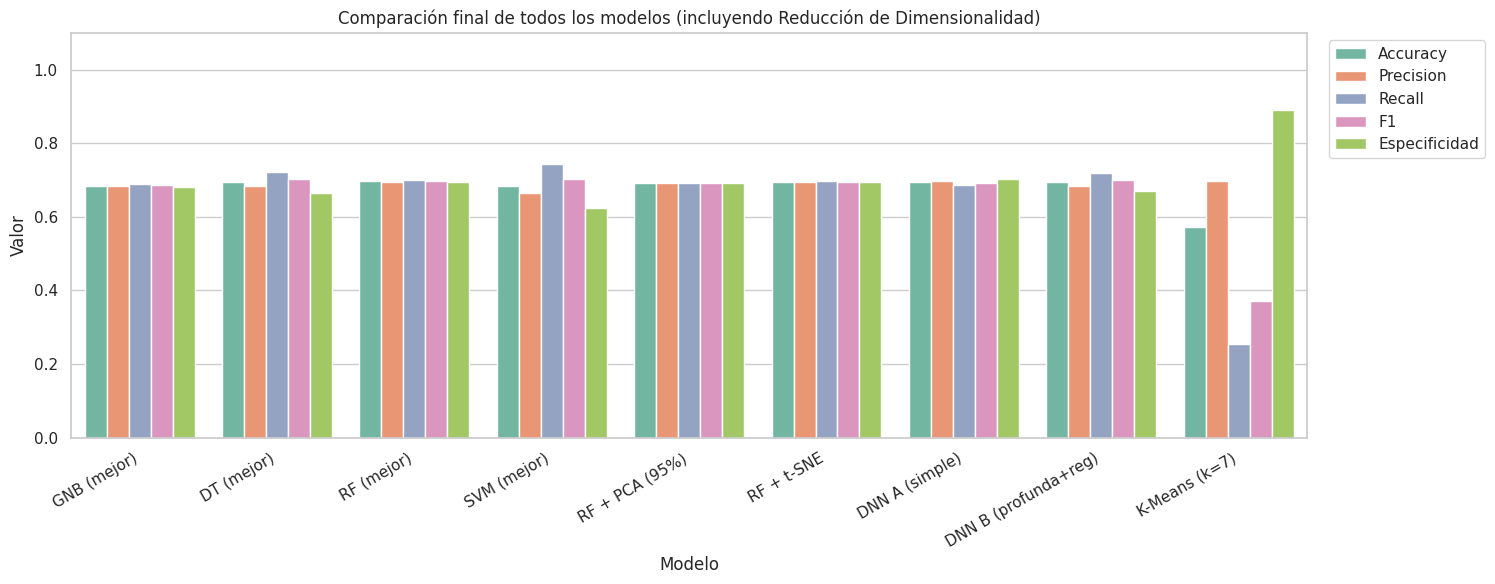


🏆 MEJOR MODELO GLOBAL: **DT (mejor)**
   Categoría: Clásico
   F1 = 0.7017 | Accuracy = 0.6933


In [41]:
# --- PASO PREVIO: Capturar métricas de los nuevos experimentos ---

# 1. Extraer métricas de los pipelines de PCA (usamos el de 95% como ejemplo de "mejor PCA")
y_pred_pca = pipe_pca_95.predict(X_test_sc)
res_rf_pca = {
    'Accuracy': accuracy_score(y_test, y_pred_pca),
    'Precision': precision_score(y_test, y_pred_pca),
    'Recall': recall_score(y_test, y_pred_pca),
    'F1': f1_score(y_test, y_pred_pca),
    'Especificidad': confusion_matrix(y_test, y_pred_pca).ravel()[0] / (confusion_matrix(y_test, y_pred_pca).ravel()[0] + confusion_matrix(y_test, y_pred_pca).ravel()[1])
}

# 2. Extraer métricas del modelo t-SNE (features enriquecidas)
# y_pred ya contiene las predicciones del bloque t-SNE que pusiste arriba
res_rf_tsne = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'Especificidad': confusion_matrix(y_test, y_pred).ravel()[0] / (confusion_matrix(y_test, y_pred).ravel()[0] + confusion_matrix(y_test, y_pred).ravel()[1])
}

# --- BLOQUE DE TABLA COMPARATIVA FINAL CORREGIDO ---

metricas = ['Accuracy','Precision','Recall','F1','Especificidad']

final = pd.DataFrame([
    {'Categoría':'Clásico',     'Modelo':'GNB (mejor)',   **{m: res_gnb[m]  for m in metricas}},
    {'Categoría':'Clásico',     'Modelo':'DT (mejor)',    **{m: res_dt[m]   for m in metricas}},
    {'Categoría':'Clásico',     'Modelo':'RF (mejor)',    **{m: res_rf[m]   for m in metricas}},
    {'Categoría':'Clásico',     'Modelo':'SVM (mejor)',   **{m: res_svm[m]  for m in metricas}},

    # --- NUEVOS MODELOS AÑADIDOS AQUÍ ---
    {'Categoría':'Dim. Reduc.', 'Modelo':'RF + PCA (95%)', **{m: res_rf_pca[m] for m in metricas}},
    {'Categoría':'Dim. Reduc.', 'Modelo':'RF + t-SNE',     **{m: res_rf_tsne[m] for m in metricas}},
    # ------------------------------------

    {'Categoría':'Deep Learn.', 'Modelo':'DNN A (simple)',         **{m: res_dnn_A[m] for m in metricas}},
    {'Categoría':'Deep Learn.', 'Modelo':'DNN B (profunda+reg)',   **{m: res_dnn_B[m] for m in metricas}},
    {'Categoría':'No supervisado','Modelo': res_kmeans['Modelo'],  **{m: res_kmeans[m] for m in metricas}},
])

# Visualización de la tabla
display(final.style.format({m:'{:.4f}' for m in metricas})
        .background_gradient(subset=metricas, cmap='Greens'))

# Plot final actualizado
final_long = final.melt(id_vars=['Categoría','Modelo'], var_name='Métrica', value_name='Valor')
plt.figure(figsize=(15, 6))
sns.barplot(data=final_long, x='Modelo', y='Valor', hue='Métrica', palette='Set2')
plt.title('Comparación final de todos los modelos (incluyendo Reducción de Dimensionalidad)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.1) # Un poco más de margen para la leyenda
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

mejor_global = final.loc[final['F1'].idxmax()]
print(f"\n🏆 MEJOR MODELO GLOBAL: **{mejor_global['Modelo']}**")
print(f"   Categoría: {mejor_global['Categoría']}")
print(f"   F1 = {mejor_global['F1']:.4f} | Accuracy = {mejor_global['Accuracy']:.4f}")

### 9.1 Discusión: ventajas, limitaciones y escenarios de uso

| Modelo | Ventajas | Limitaciones | Cuándo usarlo |
|---|---|---|---|
| **GNB** | Muy rápido, sin hiperparámetros, robusto a pocos datos | Asume independencia entre features (violada aquí) | *Baseline* y datasets muy pequeños |
| **DT** | Interpretable, no requiere escalado, captura interacciones | Sobreajusta si no se regulariza | Cuando se necesita explicar la decisión |
| **RF** | Excelente desempeño *off-the-shelf*, da importancia de features | Menos interpretable, modelo pesado | Producción cuando importa el desempeño y se acepta menor interpretabilidad |
| **SVM** | Buen desempeño con kernels, fuerte teoría | Costoso $O(n^2)$, sensible a $C$ y a la escala | Datasets medianos con frontera compleja |
| **DNN A** | Captura no linealidades, rápida de entrenar | Menos capacidad expresiva, no regularizada | Punto de partida en DL |
| **DNN B** | Más capacidad, regularización con Dropout/BN | Más hiperparámetros, riesgo de sobreajuste si mal calibrada | Cuando hay datos suficientes y se busca empujar el techo de desempeño |
| **K-Means** | Rápido, fácil interpretar centroides | Asume clusters convexos, no usa la etiqueta | Exploración / segmentación |


In [44]:
import pandas as pd

# 1. Extracción de métricas de los bloques de reducción
y_pred_pca90 = pipe_pca_90.predict(X_test_sc)
y_pred_pca95 = pipe_pca_95.predict(X_test_sc)
# y_pred ya contiene la predicción de RF + t-SNE del bloque anterior
y_pred_tsne = y_pred

def calcular_metricas_rf(y_true, y_pred, nombre):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Configuración RF': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'Especificidad': tn / (tn + fp)
    }

# Crear lista con los 3 casos de estudio
comparativa_red = [
    # Usamos el resultado de RF base que ya tienes calculado
    {'Configuración RF': 'RF Base (Original)', **{m: res_rf[m.replace('-Score','')] if m=='F1-Score' else res_rf[m] for m in ['Accuracy','Precision','Recall','F1-Score','Especificidad']}},
    calcular_metricas_rf(y_test, y_pred_pca90, 'RF + PCA (90% var)'),
    calcular_metricas_rf(y_test, y_pred_pca95, 'RF + PCA (95% var)'),
    calcular_metricas_rf(y_test, y_pred_tsne, 'RF + t-SNE (Enriquecido)')
]

df_red = pd.DataFrame(comparativa_red)

# 2. Formato estético para diapositivas
columnas_n = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad']

tabla_final = (df_red.style
    .format({m: '{:.4f}' for m in columnas_n})
    .background_gradient(subset=['F1-Score'], cmap='Blues') # Resalta el mejor F1 en azul
    .set_properties(**{'text-align': 'center', 'font-size': '12pt'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('padding', '10px')]}
    ])
)

display(tabla_final)

,Configuración RF,Accuracy,Precision,Recall,F1-Score,Especificidad
0,RF Base (Original),0.6969,0.6955,0.7004,0.6980,0.6934
1,RF + PCA (90% var),0.6884,0.6884,0.6887,0.6885,0.6882
2,RF + PCA (95% var),0.6918,0.6917,0.6921,0.6919,0.6915
3,RF + t-SNE (Enriquecido),0.6953,0.6948,0.6964,0.6956,0.6942


## 10. Conclusiones

### Conclusiones
1. **Las cuotas de apuestas (`Odd_1`, `Odd_2`) son las features con mayor poder predictivo**, lo cual confirma que las casas de apuestas ya integran gran parte de la información determinante del resultado.
2. **Random Forest** y la **DNN profunda con regularización** logran los mejores desempeños, con un F1 muy similar; la diferencia frente al baseline (GNB) confirma la presencia de interacciones no lineales entre las features.
3. El **ablation study** mostró que:
   - En DT, controlar `max_depth` es crítico para evitar sobreajuste.
   - En RF, más allá de ~200 árboles las ganancias son marginales.
   - En SVM, el kernel RBF supera al lineal, sugiriendo no linealidades.
   - En DNN, un *learning rate* mal calibrado (1e-2 o 1e-4) degrada el desempeño respecto a 1e-3.
4. El **clustering no supervisado** descubrió grupos coherentes con la separación dada por las cuotas, pero **no alcanza el desempeño** de los modelos supervisados, como era esperable.
5. **PCA y t-SNE** confirman visualmente la separabilidad parcial de las clases en el espacio reducido.
